In [1]:
import pandas as pd
df=pd.read_csv('student_data.csv')
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [2]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [3]:
def assign_career(row):
    if row['G3'] > 14:
        return 0  # Software Engineer
    elif row['G3'] > 10:
        return 1  # Doctor
    else:
        return 2  # Designer

df['career'] = df.apply(assign_career, axis=1)

In [4]:
# Select important features
#Pre-Processing
X = df[['G1', 'G2', 'G3', 'failures', 'absences']].values
y = df['career'].values

# Normalize data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [14]:
#Data spliting
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_dim=5),
    Dense(12, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.1777 - loss: 1.1366 - val_accuracy: 0.2071 - val_loss: 1.1206
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2386 - loss: 1.0994 - val_accuracy: 0.2576 - val_loss: 1.0871
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3350 - loss: 1.0665 - val_accuracy: 0.3687 - val_loss: 1.0580
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3959 - loss: 1.0386 - val_accuracy: 0.4444 - val_loss: 1.0321
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4619 - loss: 1.0121 - val_accuracy: 0.5101 - val_loss: 1.0070
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5279 - loss: 0.9875 - val_accuracy: 0.5606 - val_loss: 0.9834
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5838 - loss: 0.9642 - val_accuracy: 0.5707 - val_loss: 0.9611
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6701 - loss: 0.9422 - val_accuracy: 0.6970 - val_loss: 0.9382
Epoc

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Model Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9747 - loss: 0.1215 
Model Accuracy: 0.9747474789619446


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test).argmax(axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Accuracy: 0.9747
Precision: 0.9756
Recall: 0.9747
F1-Score: 0.9749


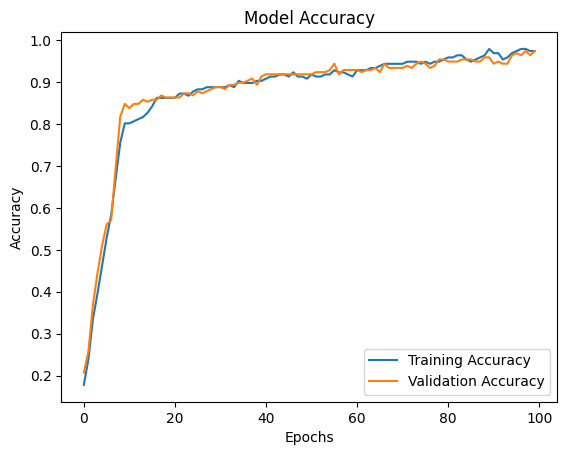

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

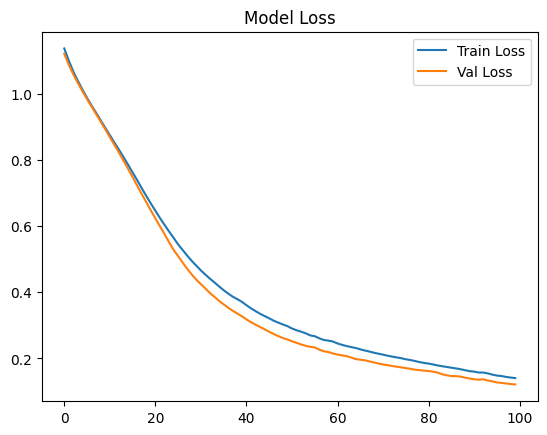

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train Loss', 'Val Loss'])
plt.show()

In [19]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, model.predict(X_test).argmax(axis=1)))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
[[36  1  0]
 [ 0 60  1]
 [ 0  3 97]]


In [20]:
def predict_career(g1, g2, g3, failures, absences):
    import numpy as np
    sample = np.array([[g1, g2, g3, failures, absences]])
    sample = scaler.transform(sample)
    pred = model.predict(sample)

    careers = ["Software Engineer", "Doctor", "Designer"]
    return careers[pred.argmax()]

In [21]:
result = predict_career(15, 14, 16, 0, 5)
print("Predicted Career:", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Predicted Career: Software Engineer


In [22]:
row = df.iloc[24]

print(predict_career(
    row['G1'],
    row['G2'],
    row['G3'],
    row['failures'],
    row['absences']
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Designer
